# Heart Disease UCI - Exploratory Data Analysis

**Dataset:** Cleveland Heart Disease Database (UCI ML Repository)  
**Source:** Robert Detrano, M.D., Ph.D., Cleveland Clinic Foundation  
**Records:** 303 patients, 14 attributes (13 features + 1 target)  
**Goal:** Binary classification -- presence (1) vs absence (0) of heart disease

In [2]:
import sys
sys.path.insert(0, '..')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['figure.dpi'] = 100

## 1. Load Processed Data

In [3]:
df = pd.read_csv('../dataprocessing/processed_cleveland.csv')
print(f'Dataset shape: {df.shape}')
print(f'Missing values: {df.isna().sum().sum()}')
df.head(10)

Dataset shape: (303, 14)
Missing values: 0


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145.0,233.0,1,2,150.0,0,2.3,3,0,6,0
1,67,1,4,160.0,286.0,0,2,108.0,1,1.5,2,3,3,1
2,67,1,4,120.0,229.0,0,2,129.0,1,2.6,2,2,7,1
3,37,1,3,130.0,250.0,0,0,187.0,0,3.5,3,0,3,0
4,41,0,2,130.0,204.0,0,2,172.0,0,1.4,1,0,3,0
5,56,1,2,120.0,236.0,0,0,178.0,0,0.8,1,0,3,0
6,62,0,4,140.0,268.0,0,2,160.0,0,3.6,3,2,3,1
7,57,0,4,120.0,354.0,0,0,163.0,1,0.6,1,0,3,0
8,63,1,4,130.0,254.0,0,2,147.0,0,1.4,2,1,7,1
9,53,1,4,140.0,203.0,1,2,155.0,1,3.1,3,0,7,1


## 2. Summary Statistics

In [4]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,303.0,54.438944,9.038662,29.0,48.0,56.0,61.0,77.0
sex,303.0,0.679868,0.467299,0.0,0.0,1.0,1.0,1.0
cp,303.0,3.158416,0.960126,1.0,3.0,3.0,4.0,4.0
trestbps,303.0,131.689769,17.599748,94.0,120.0,130.0,140.0,200.0
chol,303.0,246.693069,51.776918,126.0,211.0,241.0,275.0,564.0
fbs,303.0,0.148515,0.356198,0.0,0.0,0.0,0.0,1.0
restecg,303.0,0.990099,0.994971,0.0,0.0,1.0,2.0,2.0
thalach,303.0,149.607261,22.875003,71.0,133.5,153.0,166.0,202.0
exang,303.0,0.326733,0.469794,0.0,0.0,0.0,1.0,1.0
oldpeak,303.0,1.039604,1.161075,0.0,0.0,0.8,1.6,6.2


In [5]:
print('Column types:')
print(df.dtypes)
print()
print('Unique values per column:')
for col in df.columns:
    print(f'  {col}: {df[col].nunique()} unique -> {sorted(df[col].unique())[:10]}')

Column types:
age           int64
sex           int64
cp            int64
trestbps    float64
chol        float64
fbs           int64
restecg       int64
thalach     float64
exang         int64
oldpeak     float64
slope         int64
ca            int64
thal          int64
target        int64
dtype: object

Unique values per column:
  age: 41 unique -> [np.int64(29), np.int64(34), np.int64(35), np.int64(37), np.int64(38), np.int64(39), np.int64(40), np.int64(41), np.int64(42), np.int64(43)]
  sex: 2 unique -> [np.int64(0), np.int64(1)]
  cp: 4 unique -> [np.int64(1), np.int64(2), np.int64(3), np.int64(4)]
  trestbps: 50 unique -> [np.float64(94.0), np.float64(100.0), np.float64(101.0), np.float64(102.0), np.float64(104.0), np.float64(105.0), np.float64(106.0), np.float64(108.0), np.float64(110.0), np.float64(112.0)]
  chol: 152 unique -> [np.float64(126.0), np.float64(131.0), np.float64(141.0), np.float64(149.0), np.float64(157.0), np.float64(160.0), np.float64(164.0), np.float64(166.0

## 3. Target Distribution (Class Balance)

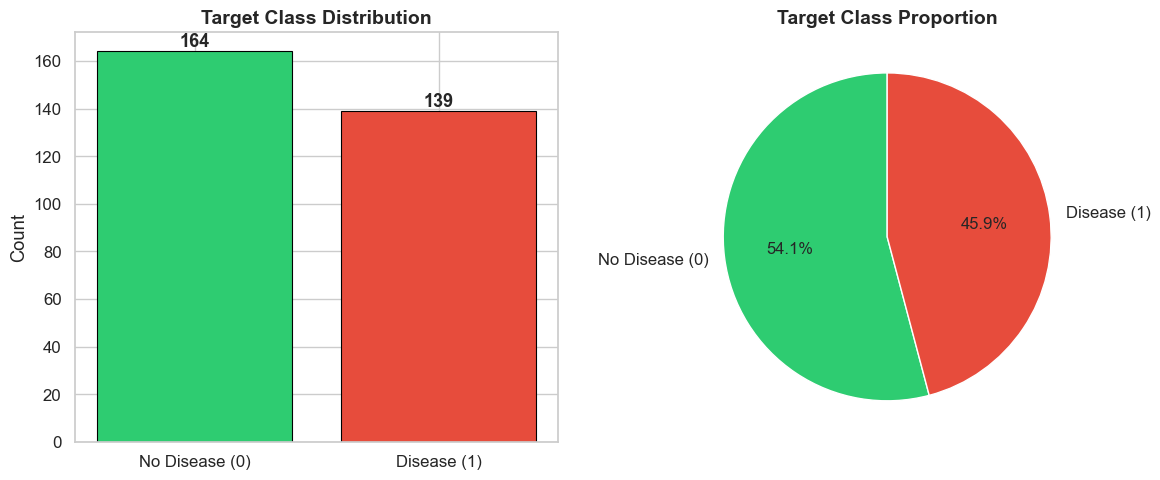

Class ratio: 164:139 = 1.18:1


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

target_counts = df['target'].value_counts()
labels = ['No Disease (0)', 'Disease (1)']
colors = ['#2ecc71', '#e74c3c']

axes[0].bar(labels, target_counts.values, color=colors, edgecolor='black', linewidth=0.8)
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold', fontsize=13)
axes[0].set_title('Target Class Distribution', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')

axes[1].pie(target_counts.values, labels=labels, colors=colors, autopct='%1.1f%%',
            startangle=90, textprops={'fontsize': 12})
axes[1].set_title('Target Class Proportion', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('../screenshots/class_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Class ratio: {target_counts[0]}:{target_counts[1]} = {target_counts[0]/target_counts[1]:.2f}:1')

## 4. Feature Histograms

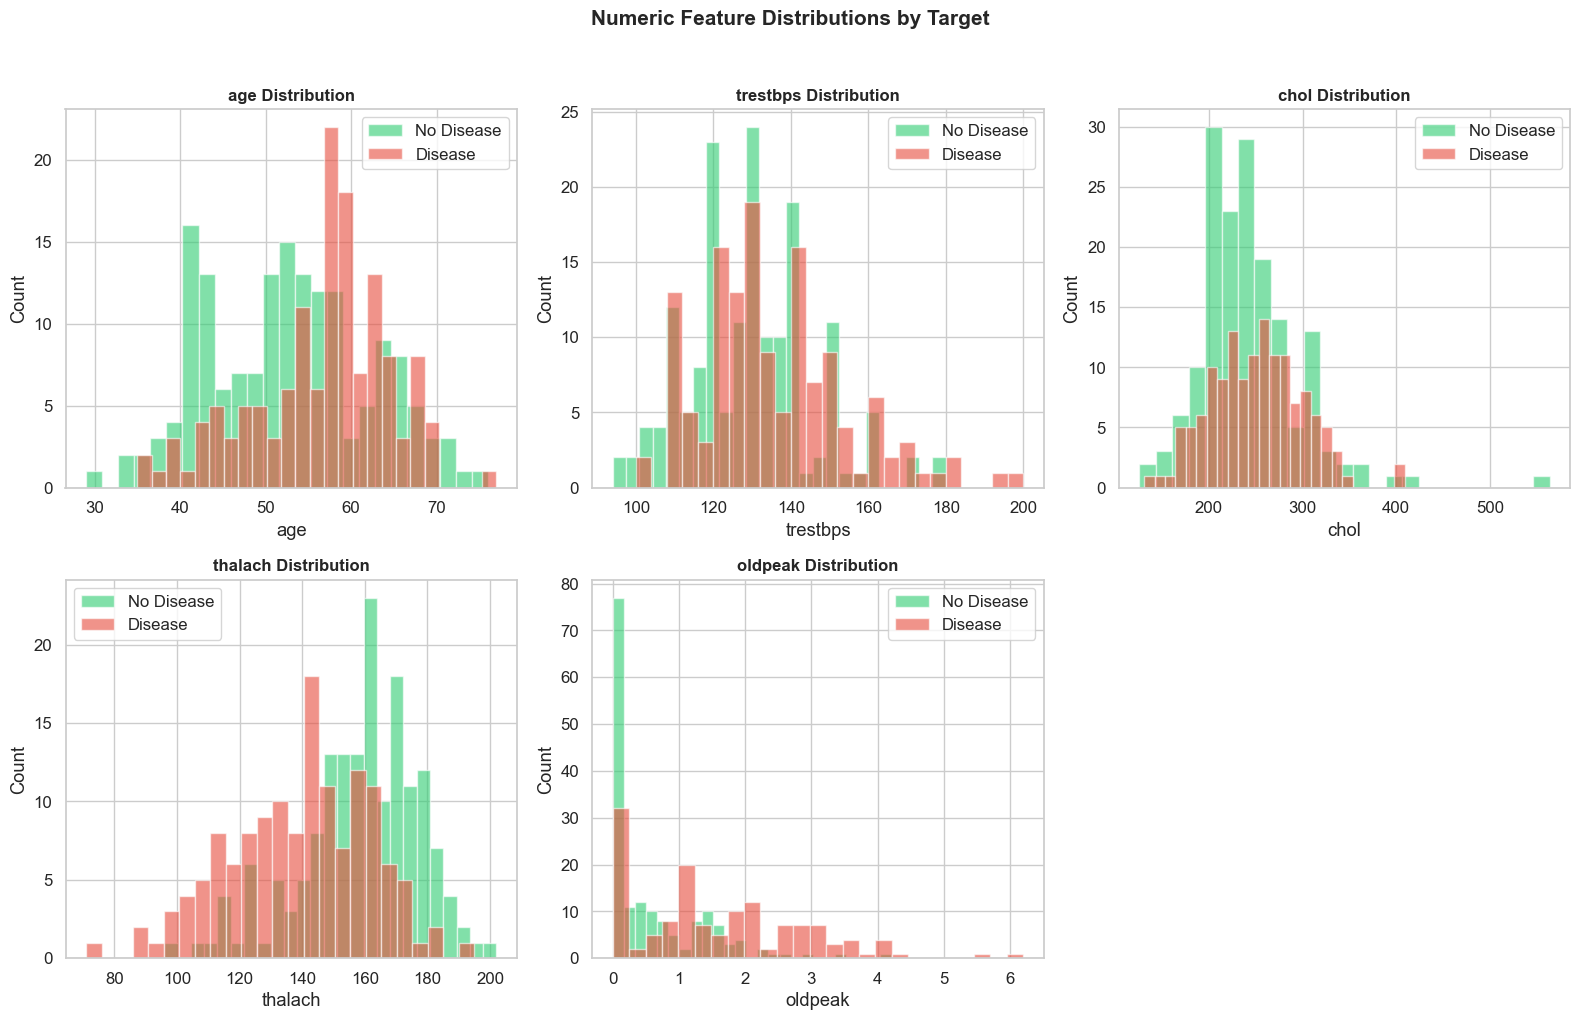

In [7]:
numeric_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    ax = axes[i]
    for label, color in zip([0, 1], colors):
        subset = df[df['target'] == label][col]
        ax.hist(subset, bins=25, alpha=0.6, color=color,
                label=f'{"No Disease" if label == 0 else "Disease"}')
    ax.set_title(f'{col} Distribution', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

axes[-1].axis('off')
plt.suptitle('Numeric Feature Distributions by Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/feature_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

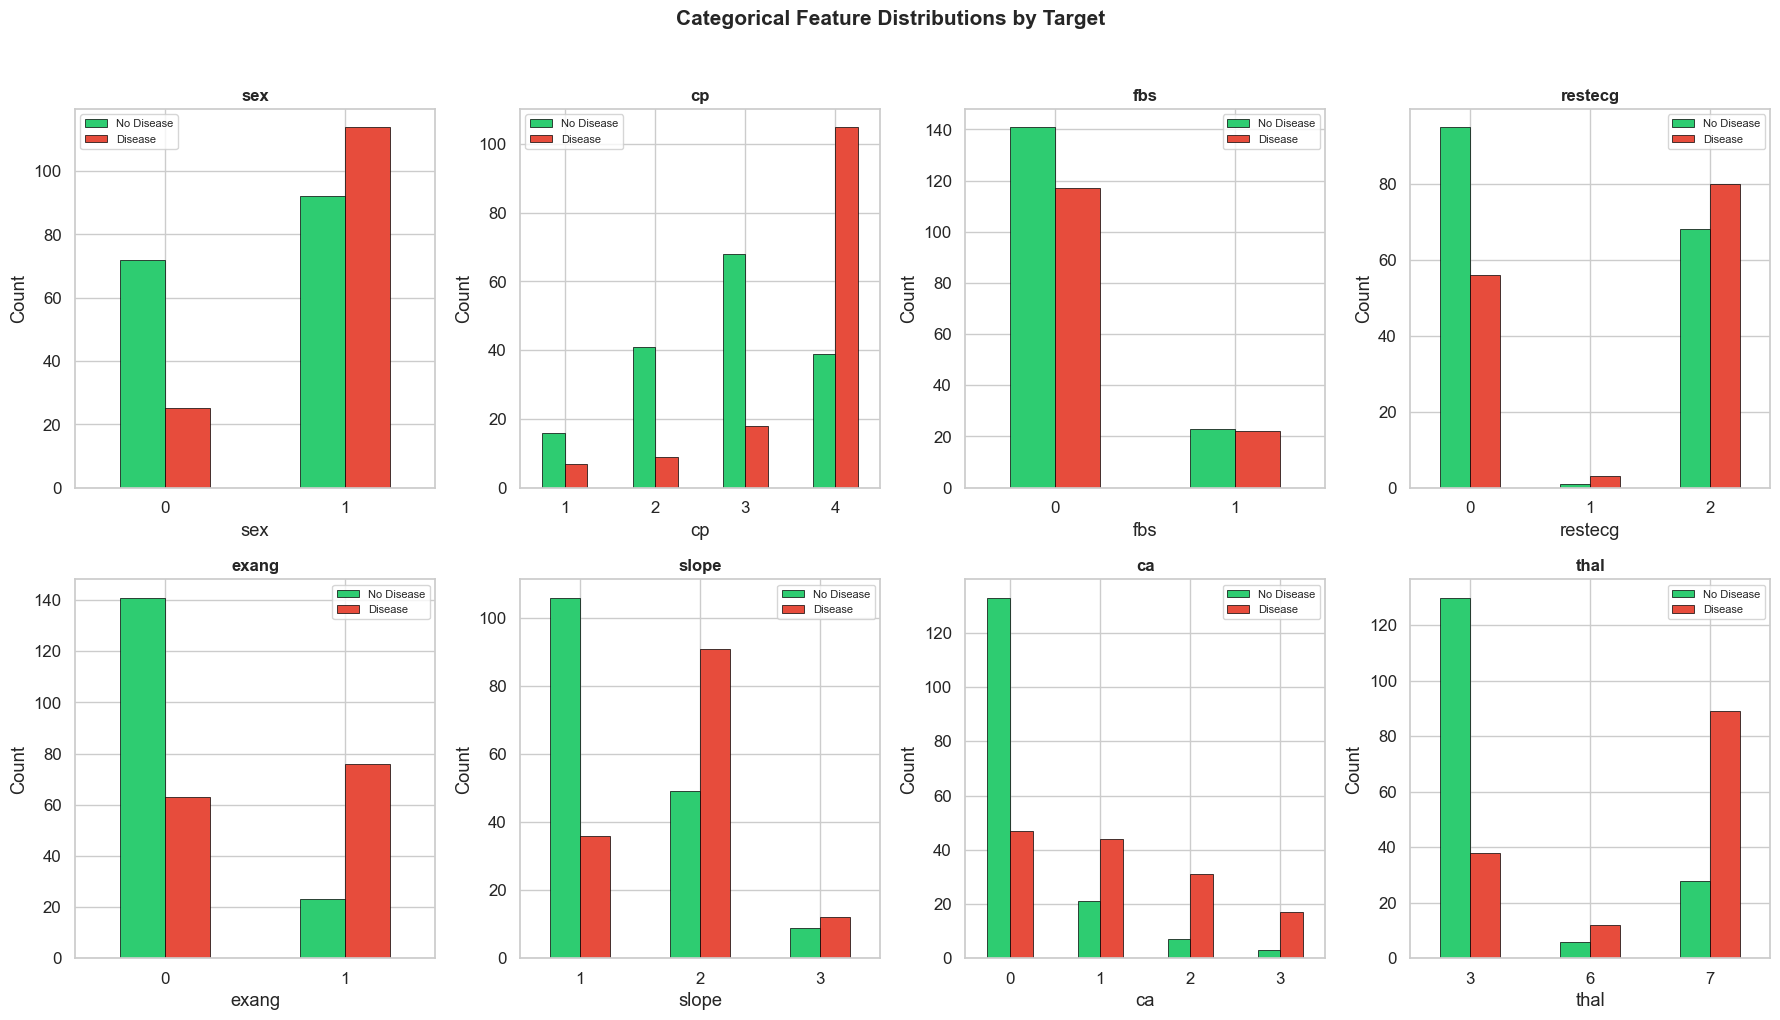

In [8]:
cat_cols = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']
fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = axes[i]
    ct = pd.crosstab(df[col], df['target'])
    ct.plot(kind='bar', ax=ax, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(f'{col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend(['No Disease', 'Disease'], fontsize=8)
    ax.tick_params(axis='x', rotation=0)

plt.suptitle('Categorical Feature Distributions by Target', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../screenshots/categorical_features.png', dpi=150, bbox_inches='tight')
plt.show()

## 5. Correlation Heatmap

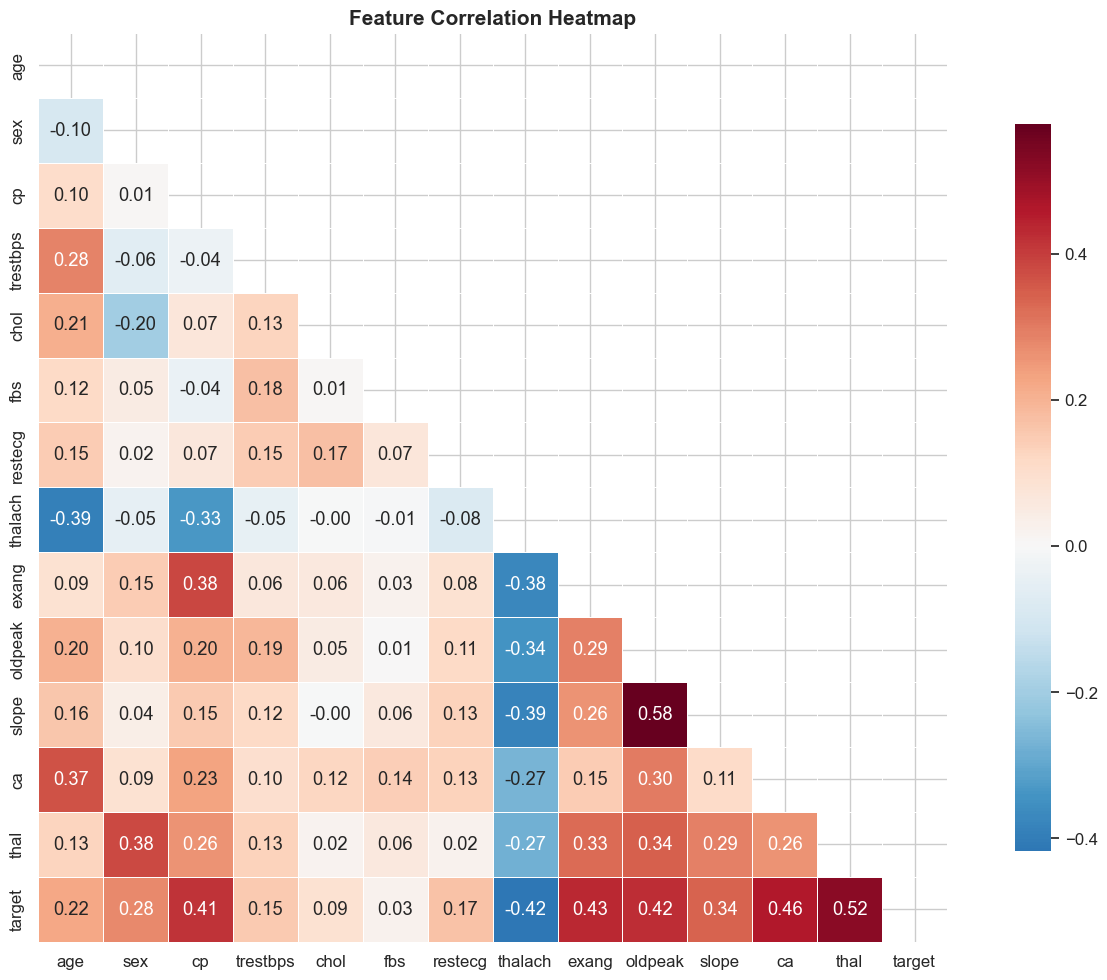


Top correlations with target:
  thal        : +0.522
  ca          : +0.460
  exang       : +0.432
  oldpeak     : +0.425
  thalach     : -0.417
  cp          : +0.414
  slope       : +0.339
  sex         : +0.277
  age         : +0.223
  restecg     : +0.169
  trestbps    : +0.151
  chol        : +0.085
  fbs         : +0.025


In [9]:
fig, ax = plt.subplots(figsize=(14, 10))
corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, square=True, linewidths=0.5, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('../screenshots/correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nTop correlations with target:')
target_corr = corr['target'].drop('target').abs().sort_values(ascending=False)
for feat, val in target_corr.items():
    print(f'  {feat:12s}: {corr["target"][feat]:+.3f}')

## 6. Pairplot of Key Features

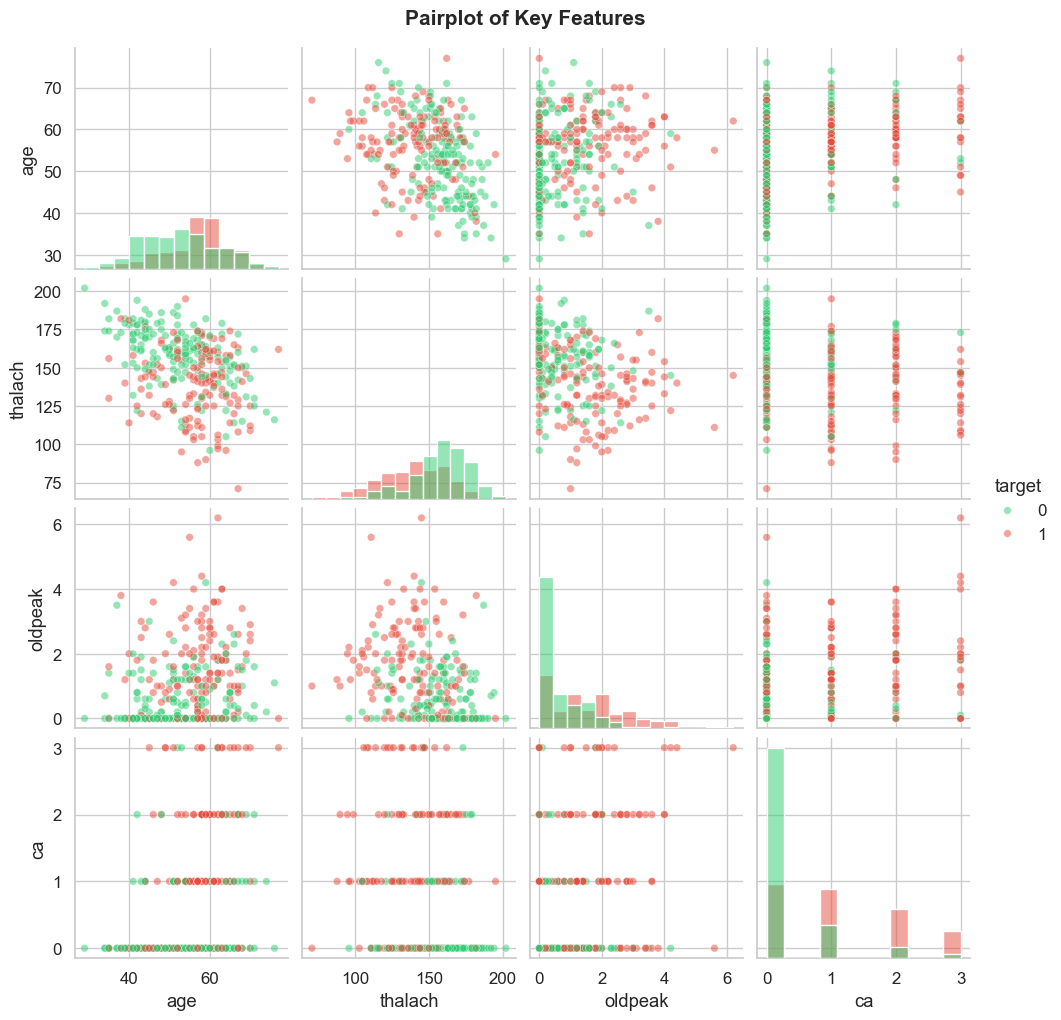

In [10]:
key_features = ['age', 'thalach', 'oldpeak', 'ca', 'target']
g = sns.pairplot(df[key_features], hue='target', palette={0: '#2ecc71', 1: '#e74c3c'},
                 diag_kind='hist', plot_kws={'alpha': 0.5, 's': 30})
g.figure.suptitle('Pairplot of Key Features', y=1.02, fontsize=15, fontweight='bold')
plt.savefig('../screenshots/pairplot.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Key EDA Findings

1. **Class balance:** The dataset is reasonably balanced (~54% no disease, ~46% disease)
2. **Strongest predictors:** `thal`, `ca`, `oldpeak`, `exang`, `cp` show the highest correlations with the target
3. **Age:** Patients with heart disease tend to be slightly older
4. **Max heart rate (thalach):** Lower max heart rate is associated with disease presence
5. **ST depression (oldpeak):** Higher values correlate with disease
6. **Chest pain type (cp):** Type 4 (asymptomatic) is strongly associated with disease
7. **Missing values:** Only 6 values were missing (4 in `ca`, 2 in `thal`), imputed with mode